<a href="https://colab.research.google.com/github/Jun-0001/Smoking-Health-Data-Analysis/blob/main/Chill_stack_1_2_%E1%84%83%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A5%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8_0122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### AI 헬스케어 첫번째 미니 프로젝트 “흡연 여부 데이터 분석을 통한 건강 인사이트 도출” 에 오신 여러분 환영합니다.
이번 프로젝트에서는 흡연여부를 판단하는 데이터를 가지고 시각화 및 가설을 판별해보려고 합니다.


A-Z로 진행되는 만큼 천천히 따라해보세요!

#### 팀 과제
- 데이터 구조, 분포 확인, 전처리 : 1.1_흡연여부데이터
- 데이터 간 관계 가설 수립 및 검증 : 1.2_데이터분석



### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련


# 0. 필수 라이브러리 설치

In [ ]:
# 필요한 라이브러리들 불러오기

# 나눔폰트 설치 (Linux 명령어)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐

print("라이브러리 로딩 완료!")

폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!
라이브러리 로딩 완료!


In [ ]:
health_data = pd.read_csv("smoking_health_data.csv")




---



### 1. 가설 수립 (인당 최소 3개)

건강 지표별로 흡연자/비흡연자 간 통계적 차이 검증

(예시)
- H₀ (귀무가설): BMI- 흡연자와 비흡연자의 평균 BMI는 같다.
- H₁ (대립가설): BMI- 흡연자와 비흡연자의 평균 BMI는 다르다.

In [ ]:
### 아래에 3가지의 가설을 설정해보세요.

# 1.
# H₀ (귀무가설): 헤모글로빈- 흡연자와 비흡연자의 평균 헤모글로빈 농도 차이가 없다.
# H₁ (대립가설): 헤모글로빈- 흡연자와 비흡연자의 평균 헤모글로빈 농도가  차이가 있다.

# 2.
# H₀ (귀무가설): 요단백- 흡연자와 비흡연자의 요단백 수치차이가 없다.
# H₁ (대립가설): 요단백- 흡연자와 비흡연자의 요단백 수치차이가 있다.

# 3.
# H₀ (귀무가설): 충치- 흡연자와 비흡연자의 충치 유무 비율차이가 없다.
# H₁ (대립가설): 충치- 흡연자와 비흡연자의 충치 유무 비율차이가 있다.

# 4.
# H₀ (귀무가설): 공복 혈당 - 흡연 여부에 따른 공복 혈당 차이가 없다.
# H₁ (대립가설): 공복 혈당 - 흡연 여부에 따른 공복 혈당 차이가 있다.

# 5.
# H₀ (귀무가설): BMI - 흡연 여부에 따른 비만 비율 차이가 없다
# H₁ (대립가설): BMI - 흡연 여부에 따른 비만 비율 차이가 없다



## 2. 단변량 분석

	단변량 분석 의미 찾기:

    •	데이터 품질(결측, 이상치) 확인

    •	모델 입력값 기준 설정

- 숫자형, 범주형
- 전처리 사항
  - NaN 존재 여부 및 조치 방안
  - 가변수화 대상여부
- 기초통계량 확인
- 분포 확인
- 위 정보로부터 파악한 비즈니스 내용 정리
- 추가 분석해볼 사항 도출

# 결측치 대체

In [ ]:
# 단변량 분석 전 BMI_Category 추가
patients_bmi = health_data["BMI"]
BMI_Category = []

for patient_bmi in patients_bmi:
  if patient_bmi < 18.5:
    BMI_Category.append('저체중')
  elif patient_bmi < 25:
    BMI_Category.append('정상')
  elif patient_bmi < 30:
    BMI_Category.append('과체중')
  else:
    BMI_Category.append('비만')

health_data["BMI_Category"] = BMI_Category
health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI_Category
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중


In [ ]:
# 단변량 분석 전 age_group 추가
patients_age = health_data["나이"]
age_group = []

for patient_age in patients_age:
  if patient_age <= 30:
    age_group.append("30대 이하")
  elif patient_age <= 50:
    age_group.append("30~50대")
  elif patient_age <= 70:
    age_group.append("50~70대")
  else:
    age_group.append("70대 이상")


health_data["age_group"] = age_group
health_data.tail()


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI_Category,age_group
6995,TRAIN_6995,25,170,65,22.49,1.50,0,87.0,45.0,141.0,1.2,184,44,112,14.9,1,1.50,0,정상,30대 이하
6996,TRAIN_6996,60,165,65,23.88,0.90,0,87.0,45.0,82.0,0.9,184,64,103,14.3,1,1.47,1,정상,50~70대
6997,TRAIN_6997,40,180,100,30.86,1.20,0,97.0,44.0,87.0,0.9,178,54,107,15.6,1,1.00,0,비만,30~50대
6998,TRAIN_6998,60,150,55,24.44,0.60,0,89.0,57.0,161.0,0.6,157,49,76,14.4,1,1.00,0,정상,50~70대
6999,TRAIN_6999,50,165,65,23.88,0.65,0,104.0,47.0,124.0,0.8,251,56,170,13.6,1,0.81,0,정상,30~50대


In [ ]:
# 원본 백업
health_data_filled = health_data.copy()

# label 컬럼 변경 -> 가독성 위해 흡연 여부로 변경
health_data_filled.rename(columns={'label': '흡연여부'}, inplace=True)

# 혈압 결측치 -> 중앙값으로 대체
bp_median = health_data_filled['혈압'].median()
health_data_filled['혈압'] = health_data_filled['혈압'].fillna(bp_median)

# 시력 결측치 -> 최빈값으로 대체
sight_mode = health_data_filled['시력'].mode()[0] # 최빈값 중 첫번째 최빈값
health_data_filled['시력'] = health_data_filled['시력'].fillna(sight_mode)
print("")

# 나이대별 중성지방 -> 각 그룹 평균값으로 대체
health_data_filled['중성 지방'] = health_data_filled.groupby('age_group')['중성 지방'].transform(lambda x: x.fillna(x.mean()))
health_data_filled.groupby('age_group')['중성 지방']

# 공복 혈당 -> 평균값으로 대체
fasting_glucose_mean = health_data_filled['공복 혈당'].mean()
health_data_filled['공복 혈당'] = health_data_filled['공복 혈당'].fillna(fasting_glucose_mean)
print("")


print("결측치 처리 후:")
print(health_data_filled.isnull().sum())




결측치 처리 후:
ID              0
나이              0
키(cm)           0
몸무게(kg)         0
BMI             0
시력              0
충치              0
공복 혈당           0
혈압              0
중성 지방           0
혈청 크레아티닌        0
콜레스테롤           0
고밀도지단백          0
저밀도지단백          0
헤모글로빈           0
요 단백            0
간 효소율           0
흡연여부            0
BMI_Category    0
age_group       0
dtype: int64


# 이상치 확인

### 연령대별 BMI 이상치 확인

       count   mean   std    min    25%    50%    75%    max
흡연여부                                                        
비흡연   4429.0  23.81  3.44  14.27  21.48  23.44  25.71  42.45
흡연    2571.0  24.73  3.53  15.57  22.49  24.22  27.06  40.82

나이 그룹 + 흡연 여부별 평균 BMI
흡연여부         비흡연     흡연
age_group              
30대 이하     24.80  24.84
30~50대     23.45  24.86
50~70대     24.06  24.19
70대 이상     23.45  22.28


30대 이하:
Q1 (25%): 22.5
Q3 (75%): 27.6
IQR: 5.1
💡 중간 50%: 22.5~27.6 (5.1 범위)
✅ 극값 무시 안정 지표

30~50대:
Q1 (25%): 21.5
Q3 (75%): 25.9
IQR: 4.5
💡 중간 50%: 21.5~25.9 (4.5 범위)
✅ 극값 무시 안정 지표

50~70대:
Q1 (25%): 22.0
Q3 (75%): 25.9
IQR: 3.9
💡 중간 50%: 22.0~25.9 (3.9 범위)
✅ 극값 무시 안정 지표

70대 이상:
Q1 (25%): 21.5
Q3 (75%): 25.4
IQR: 3.9
💡 중간 50%: 21.5~25.4 (3.9 범위)
✅ 극값 무시 안정 지표


/tmp/ipython-input-3585434625.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iqr_results = health_data_filled.groupby('age_group', sort=False)['BMI'].quantile([0.25, 0.5, 0.75]).unstack()


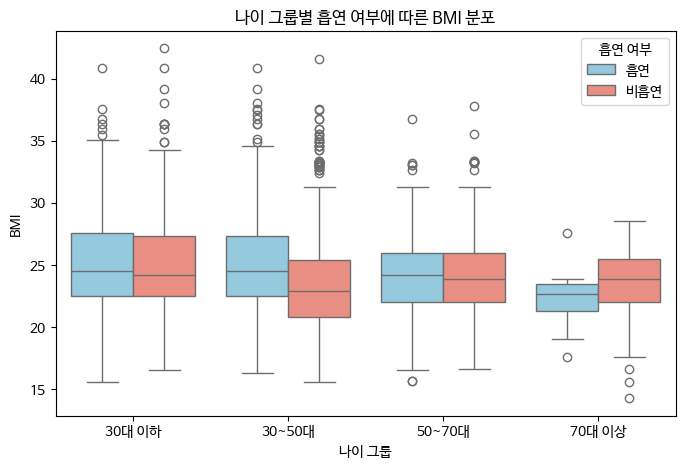

In [ ]:
# BMI 이상치

# 연령별 나누기
age_order = ["30대 이하", "30~50대", "50~70대", "70대 이상"]
health_data_filled["age_group"] = pd.Categorical(health_data_filled["age_group"], categories=age_order, ordered=True)

# 범례 변경
health_data_filled['흡연여부'] = health_data_filled['흡연여부'].replace({0.0: '비흡연', 1.0: '흡연'})


# 흡연 여부에 따른 BMI 기본 정보
bp_by_smoking = round(health_data_filled.groupby("흡연여부")["BMI"].describe(),2)

print(bp_by_smoking)
print()

#박스 플롯
bmi_mean_age_label = round(health_data_filled.groupby(["age_group", "흡연여부"],observed=False)["BMI"].mean().unstack(),2)
print("나이 그룹 + 흡연 여부별 평균 BMI")
print(bmi_mean_age_label)
print()

# BMI 기준 연령대별 IQR (순서 유지)
iqr_results = health_data_filled.groupby('age_group', sort=False)['BMI'].quantile([0.25, 0.5, 0.75]).unstack()

for age in age_order:
    q1 = iqr_results.loc[age, 0.25]
    q3 = iqr_results.loc[age, 0.75]
    iqr_val = q3 - q1

    print(f"\n{age}:")
    print(f"Q1 (25%): {q1:.1f}")
    print(f"Q3 (75%): {q3:.1f}")
    print(f"IQR: {iqr_val:.1f}")
    print(f"💡 중간 50%: {q1:.1f}~{q3:.1f} ({iqr_val:.1f} 범위)")
    print(f"✅ 극값 무시 안정 지표")


plt.figure(figsize=(8,5))
sns.boxplot(data=health_data_filled, x="age_group", y="BMI", hue="흡연여부", palette=["skyblue","salmon"])
plt.title("나이 그룹별 흡연 여부에 따른 BMI 분포")
plt.xlabel("나이 그룹")
plt.ylabel("BMI")
plt.legend(title="흡연 여부")
plt.show()


### 연령대별  헤모글로빈 이상치 확인

       count   mean   std  min   25%   50%   75%   max
흡연여부                                                  
비흡연   4429.0  14.16  1.56  4.9  13.1  14.2  15.3  19.3
흡연    2571.0  15.44  1.11  8.9  14.8  15.5  16.1  20.9

나이 그룹 + 흡연 여부별 평균 헤모글로빈 농도
흡연여부         비흡연     흡연
age_group              
30대 이하     15.56  15.73
30~50대     13.88  15.42
50~70대     14.03  15.20
70대 이상     13.83  14.45


30대 이하:
Q1 (25%): 15.0
Q3 (75%): 16.2
IQR: 1.2
💡 중간 50%: 15.0~16.2 (1.2 범위)
✅ 극값 무시 안정 지표

30~50대:
Q1 (25%): 13.4
Q3 (75%): 15.6
IQR: 2.2
💡 중간 50%: 13.4~15.6 (2.2 범위)
✅ 극값 무시 안정 지표

50~70대:
Q1 (25%): 13.3
Q3 (75%): 15.3
IQR: 2.0
💡 중간 50%: 13.3~15.3 (2.0 범위)
✅ 극값 무시 안정 지표

70대 이상:
Q1 (25%): 13.1
Q3 (75%): 15.0
IQR: 1.9
💡 중간 50%: 13.1~15.0 (1.9 범위)
✅ 극값 무시 안정 지표


/tmp/ipython-input-765903303.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iqr_results = health_data_filled.groupby('age_group', sort=False)['헤모글로빈'].quantile([0.25, 0.5, 0.75]).unstack()


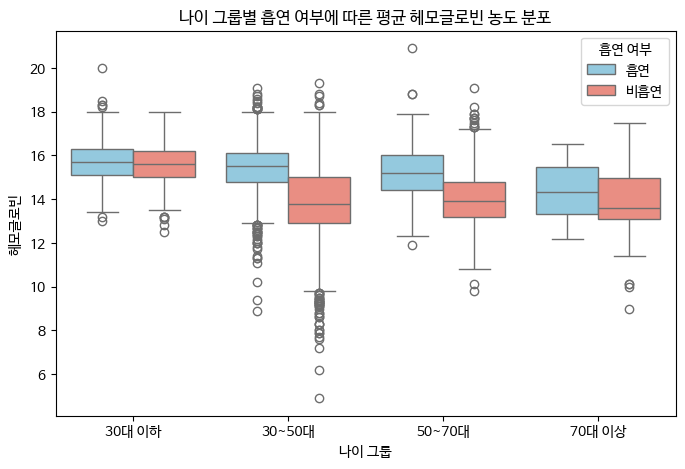

In [ ]:
# 흡연 여부에 따른 헤모글로빈 기본 정보
bp_by_hemoglobin = round(health_data_filled.groupby("흡연여부")["헤모글로빈"].describe(),2)

print(bp_by_hemoglobin)
print()


#박스 플롯
hemoglobin_mean_age_label = round(health_data_filled.groupby(["age_group", "흡연여부"],observed=False)["헤모글로빈"].mean().unstack(),2)
print("나이 그룹 + 흡연 여부별 평균 헤모글로빈 농도")
print(hemoglobin_mean_age_label)
print()

# 헤모글로빈 기준 연령대별 IQR (순서 유지)
iqr_results = health_data_filled.groupby('age_group', sort=False)['헤모글로빈'].quantile([0.25, 0.5, 0.75]).unstack()

for age in age_order:
    q1 = iqr_results.loc[age, 0.25]
    q3 = iqr_results.loc[age, 0.75]
    iqr_val = q3 - q1

    print(f"\n{age}:")
    print(f"Q1 (25%): {q1:.1f}")
    print(f"Q3 (75%): {q3:.1f}")
    print(f"IQR: {iqr_val:.1f}")
    print(f"💡 중간 50%: {q1:.1f}~{q3:.1f} ({iqr_val:.1f} 범위)")
    print(f"✅ 극값 무시 안정 지표")

plt.figure(figsize=(8,5))
sns.boxplot(data=health_data_filled, x="age_group", y="헤모글로빈", hue="흡연여부", palette=["skyblue","salmon"])
plt.title("나이 그룹별 흡연 여부에 따른 평균 헤모글로빈 농도 분포")
plt.xlabel("나이 그룹")
plt.ylabel("헤모글로빈")
plt.legend(title="흡연 여부")
plt.show()

### 연령대별  공복 혈당 이상치 확인

       count    mean    std   min   25%   50%    75%    max
흡연여부                                                       
비흡연   4429.0   97.54  17.13  57.0  88.0  95.0  102.0  313.0
흡연    2571.0  102.35  26.04  60.0  90.0  97.0  105.0  386.0

나이 그룹 + 흡연 여부별 평균 공복 혈당 농도
흡연여부          비흡연      흡연
age_group                
30대 이하      93.42   95.88
30~50대      95.92  102.64
50~70대     102.52  109.44
70대 이상     104.42  112.71


30대 이하:
Q1 (25%): 87.0
Q3 (75%): 99.3
IQR: 12.3
💡 중간 50%: 87.0~99.3 (12.3 범위)
✅ 극값 무시 안정 지표

30~50대:
Q1 (25%): 89.0
Q3 (75%): 103.0
IQR: 14.0
💡 중간 50%: 89.0~103.0 (14.0 범위)
✅ 극값 무시 안정 지표

50~70대:
Q1 (25%): 92.0
Q3 (75%): 110.0
IQR: 18.0
💡 중간 50%: 92.0~110.0 (18.0 범위)
✅ 극값 무시 안정 지표

70대 이상:
Q1 (25%): 93.0
Q3 (75%): 107.0
IQR: 14.0
💡 중간 50%: 93.0~107.0 (14.0 범위)
✅ 극값 무시 안정 지표


/tmp/ipython-input-3012546614.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iqr_results = health_data_filled.groupby('age_group', sort=False)['공복 혈당'].quantile([0.25, 0.5, 0.75]).unstack()


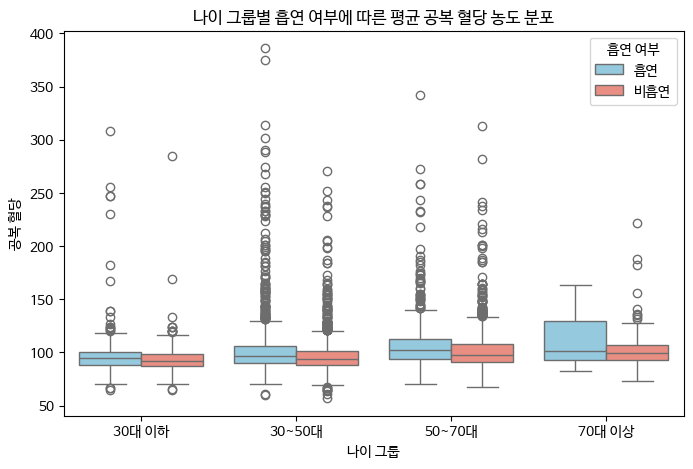

In [ ]:
# 흡연 여부에 따른 공복혈당 기본 통계 정보
bp_by_fbs = round(health_data_filled.groupby("흡연여부")["공복 혈당"].describe(),2)

print(bp_by_fbs)
print()


#박스 플롯
fbs_mean_age_label = round(health_data_filled.groupby(["age_group", "흡연여부"],observed=False)["공복 혈당"].mean().unstack(),2)
print("나이 그룹 + 흡연 여부별 평균 공복 혈당 농도")
print(fbs_mean_age_label)
print()

# 공복 혈당 기준 연령대별 IQR (순서 유지)
iqr_results = health_data_filled.groupby('age_group', sort=False)['공복 혈당'].quantile([0.25, 0.5, 0.75]).unstack()

for age in age_order:
    q1 = iqr_results.loc[age, 0.25]
    q3 = iqr_results.loc[age, 0.75]
    iqr_val = q3 - q1

    print(f"\n{age}:")
    print(f"Q1 (25%): {q1:.1f}")
    print(f"Q3 (75%): {q3:.1f}")
    print(f"IQR: {iqr_val:.1f}")
    print(f"💡 중간 50%: {q1:.1f}~{q3:.1f} ({iqr_val:.1f} 범위)")
    print(f"✅ 극값 무시 안정 지표")

plt.figure(figsize=(8,5))
sns.boxplot(data=health_data_filled, x="age_group", y="공복 혈당", hue="흡연여부", palette=["skyblue","salmon"])
plt.title("나이 그룹별 흡연 여부에 따른 평균 공복 혈당 농도 분포")
plt.xlabel("나이 그룹")
plt.ylabel("공복 혈당")
plt.legend(title="흡연 여부")
plt.show()

# 단변량 분석 (상세하게 추가하기. IQR등)
### - 기존 결측치 560개를 대체하여 0으로 만듦
### - 충치 및 요 단백의 경우 범주형 데이터이기에 이상치 분석 하지 않았음?


## 3.이변량 분석
	이변량 분석 의미 찾기:

    •	변수 간 원인–결과 관계 탐색

    •	어떤 요인이 가장 큰 영향을 주는지 도출

    •	향후 예측 모델 설계 시 주요 Feature 후보 선별

- 가설검정시 다음의 항목을 참조하여 수행합니다.
  - 유의수준 : 5%
  - 숫자 --> 숫자 : 상관분석
  - 범주 --> 범주 : 카이제곱검정
  - 범주 --> 숫자 : t검정, 분산분석
  - 숫자 --> 범주 : 로지스틱 회귀모형을 통해, 회귀계수의 P.value로 검정을 수행합니다.

# 연령대별 요 단백과 흡연 여부 이변량 분석

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 범주 --> 범주 : 카이제곱검정 -> 충치, 요 단백
# 범주 --> 숫자 : t검정, 분산분석 -> BMI, 공복 혈당, 헤모글로빈

# 이변량 라이브러리
from scipy.stats import chi2_contingency # 카이제곱
from scipy.stats import ttest_ind # t-test

age_order = ["30대 이하", "30~50대", "50~70대", "70대 이상"]

# 요단백 카이제곱 분석
for age in age_order:
    subset = health_data_filled[health_data_filled["age_group"] == age]
    table = pd.crosstab(subset['요 단백'], subset['흡연여부'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{age} 그룹:")
    print(table)
    print(f"p-value: {p:.4f}")
    if p < 0.05:
        print("→ 요 단백과 흡연 여부는 통계적으로 연관 있음★ (유의수준 5%)")
    else:
        print("→ 요 단백과 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)")

30대 이하 그룹:
흡연여부  비흡연   흡연
요 단백          
1     594  537
2      25   18
3       5    8
4       2    0
p-value: 0.3372
→ 요 단백과 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)
30~50대 그룹:
흡연여부   비흡연    흡연
요 단백            
1     2361  1488
2       98    45
3       35    21
4        9     7
5        2     2
p-value: 0.4851
→ 요 단백과 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)
50~70대 그룹:
흡연여부   비흡연   흡연
요 단백           
1     1137  400
2       31   12
3       22   12
4        9    7
5        4    0
p-value: 0.2431
→ 요 단백과 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)
70대 이상 그룹:
흡연여부  비흡연  흡연
요 단백         
1      88  13
2       2   0
3       3   1
5       2   0
p-value: 0.7728
→ 요 단백과 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)


In [ ]:
health_data_filled["흡연여부"] = health_data_filled["흡연여부"].map({0: "비흡연", 1: "흡연"})

g = sns.catplot(
    data=health_data_filled,
    x="age_group",
    hue="요 단백",
    col="흡연여부",
    kind="count",
    palette="Set2",
    height=5,
    aspect=1
)
g.set_axis_labels("나이 그룹", "인원 수")
g.set_titles("{col_name}")
g._legend.set_title("요 단백 단계")
plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>

# 연령대별 충치 여부와 흡연 여부 이변량 분석

In [ ]:
# 충치 카이제곱 분석

for age in age_order:
    subset = health_data_filled[health_data_filled["age_group"] == age]
    table = pd.crosstab(subset['충치'], subset['흡연여부'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{age} 그룹:")
    print(table)
    print(f"p-value: {p:.4f}")
    if p < 0.05:
        print("→ 충치와 흡연 여부는 통계적으로 연관 있음★ (유의수준 5%)")
    else:
        print("→ 충치와 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)")

30대 이하 그룹:
흡연여부  비흡연   흡연
충치            
0     449  364
1     177  199
p-value: 0.0106
→ 충치와 흡연 여부는 통계적으로 연관 있음★ (유의수준 5%)
30~50대 그룹:
흡연여부   비흡연    흡연
충치              
0     2018  1121
1      487   442
p-value: 0.0000
→ 충치와 흡연 여부는 통계적으로 연관 있음★ (유의수준 5%)
50~70대 그룹:
흡연여부   비흡연   흡연
충치             
0     1018  349
1      185   82
p-value: 0.0927
→ 충치와 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)
70대 이상 그룹:
흡연여부  비흡연  흡연
충치           
0      76  13
1      19   1
p-value: 0.4292
→ 충치와 흡연 여부는 통계적으로 연관 없음 (유의수준 5%)


# 연령대별 BMI 수치와 흡연 여부 이변량 분석

In [ ]:
t_results = []

for age in age_order:
    subset = health_data_filled[health_data_filled["age_group"] == age]

    group0 = subset[subset['흡연여부']=='비흡연']['BMI']
    group1 = subset[subset['흡연여부']=='흡연']['BMI']

    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)  # equal_var=False -> Welch t-test
    t_results.append({
        "나이 그룹": age,
        "t-stat": t_stat.round(2),
        "p-value": p_val.round(2)
    })

# 데이터프레임 변환
t_df = pd.DataFrame(t_results)
print("=== 나이 그룹별 t-검정 결과 (BMI ~ 흡연여부) ===")
print(t_df)

=== 나이 그룹별 t-검정 결과 (BMI ~ 흡연여부) ===
    나이 그룹  t-stat  p-value
0  30대 이하   -0.19     0.85
1  30~50대  -12.45     0.00
2  50~70대   -0.73     0.47
3  70대 이상    1.66     0.11


# 연령대별 공복 혈당 수치와 흡연 여부 이변량 분석

In [ ]:
t_results = []

for age in age_order:
    subset = health_data_filled[health_data_filled["age_group"] == age]

    group0 = subset[subset['흡연여부']=='비흡연']['공복 혈당']
    group1 = subset[subset['흡연여부']=='흡연']['공복 혈당']

    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)  # equal_var=False -> Welch t-test
    t_results.append({
        "나이 그룹": age,
        "t-stat": t_stat.round(2),
        "p-value": p_val.round(2)
    })

# 데이터프레임 변환
t_df = pd.DataFrame(t_results)
print("=== 나이 그룹별 t-검정 결과 (공복 혈당 ~ 흡연여부) ===")
print(t_df)

=== 나이 그룹별 t-검정 결과 (공복 혈당 ~ 흡연여부) ===
    나이 그룹  t-stat  p-value
0  30대 이하   -2.58     0.01
1  30~50대   -9.08     0.00
2  50~70대   -4.53     0.00
3  70대 이상   -1.13     0.28


# 연령대별 헤모글로빈 수치와 흡연 여부 이변량 분석

In [ ]:

t_results = []

for age in age_order:
    subset = health_data_filled[health_data_filled["age_group"] == age]

    group0 = subset[subset['흡연여부']=='비흡연']['헤모글로빈']
    group1 = subset[subset['흡연여부']=='흡연']['헤모글로빈']

    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)  # equal_var=False -> Welch t-test
    t_results.append({
        "나이 그룹": age,
        "t-stat": t_stat.round(2),
        "p-value": p_val.round(2)
    })

# 데이터프레임 변환
t_df = pd.DataFrame(t_results)
print("=== 나이 그룹별 t-검정 결과 (헤모글로빈 ~ 흡연여부) ===")
print(t_df)


=== 나이 그룹별 t-검정 결과 (헤모글로빈 ~ 흡연여부) ===
    나이 그룹  t-stat  p-value
0  30대 이하   -3.11     0.00
1  30~50대  -35.59     0.00
2  50~70대  -17.03     0.00
3  70대 이상   -1.59     0.13


# Heatmap

추가적으로 각 건강 지표 간의 관계도 이해해봅시다!
예를 들어, BMI, 혈압, 혈당, 콜레스테롤 등의 수치형 변수들은 서로 영향을 주고받을 수 있으며, 이를 통해 건강 상태를 종합적으로 이해하거나, 향후 모델 설계 및 연구 방향을 제안할 수 있습니다.
추가적인 인사이트를 얻어볼까요 ?

### 상관계수를 구하고 HeatMap으로 시각화 후 분석을 해보세요.
- Heatmap: 변수 간의 상관관계(Correlation)를 색상으로 쉽게 확인할 수 있는 시각화 방법입니다.
- 해석 기준:
  - 값이 1에 가까울수록 → 강한 양의 상관관계
  - 값이 -1에 가까울수록 → 강한 음의 상관관계
  - 값이 0에 가까울수록 → 관계가 약함

이를 통해 변수 간 관계를 한눈에 비교하고, 분석에 필요한 주요 변수를 파악할 수 있습니다.

In [ ]:
health_data_filled

In [ ]:
# 숫자 데이터 컬럼만 남기기
numeric_only = health_data_filled.select_dtypes(exclude=['object', 'category'])
health_data_filled['흡연여부'] = health_data_filled['흡연여부'].replace({'비흡연': 0.0, '흡연': 1.0})
# corr_matrix = numeric_only.corr(method='pearson')

correlation_vars = [
    '흡연여부',
    '나이',
    '키(cm)',
    '몸무게(kg)',
    'BMI',
    '시력',
    '충치',
    '혈압',
    '공복 혈당',
    '중성 지방',
    '콜레스테롤',
    '고밀도지단백',
    '저밀도지단백',
    '혈청 크레아티닌',
    '헤모글로빈',
    '요 단백',
    '간 효소율'
]
corr_matrix = numeric_only[correlation_vars].corr(method='pearson')
print("상관계수 행렬:")
print(corr_matrix.round(3))
print("\n📊 흡연여부와의 상관관계 (절댓값 기준 정렬):")
smoke_corr = corr_matrix['흡연여부'].drop('흡연여부').abs()

# 각 변수별로 상관관계 분석 및 AI 활용도 평가
for var, corr_val in smoke_corr.items():
    original_corr = corr_matrix['흡연여부'][var]  # 원래 상관계수 (음수/양수 포함)
    direction = "양의 상관관계" if original_corr > 0 else "음의 상관관계"

    # 상관관계 강도에 따른 AI 피처 중요도 분류
    if abs(original_corr) > 0.3:
        strength = "강한"
        ai_comment = "핵심 피처"
    elif abs(original_corr) > 0.1:
        strength = "보통"
        ai_comment = "고려 피처"
    else:
        strength = "약한"
        ai_comment = "약한 피처"

    print(f"  {var}: {original_corr:.3f} ({strength} {direction}) → AI: {ai_comment}")

In [ ]:
corr_cols = ["흡연여부","BMI", "공복 혈당", "헤모글로빈"]
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.flatten()

for i, age in enumerate(age_order):
    subset = health_data_filled[health_data_filled["age_group"] == age]
    corr = subset[corr_cols].corr()


    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, # 연령대별 상관관계 비교를 위해 모든 히트맵에 동일한 색상 범위(vmin=-1, vmax=1)를 적용
        vmax=1,
        ax=axes[i]
    )

    axes[i].set_title(f"<{age} 상관관계 HeatMap>")

plt.tight_layout()
plt.show()
print("")

corr_matrix = numeric_only[corr_cols].corr(method='pearson')
print("상관계수 행렬:")
print(corr_matrix.round(3))
print("\n📊 흡연여부와의 상관관계 (절댓값 기준 정렬):")
smoke_corr = corr_matrix['흡연여부'].drop('흡연여부').abs()
print("")
# # 각 변수별로 상관관계 분석 및 AI 활용도 평가
# for var, corr_val in smoke_corr.items():
#     original_corr = corr_matrix['흡연여부'][var]  # 원래 상관계수 (음수/양수 포함)
#     direction = "양의 상관관계" if original_corr > 0 else "음의 상관관계"

#     # 상관관계 강도에 따른 AI 피처 중요도 분류
#     if abs(original_corr) > 0.3:
#         strength = "강한"
#         ai_comment = "핵심 피처"
#     elif abs(original_corr) > 0.1:
#         strength = "보통"
#         ai_comment = "고려 피처"
#     else:
#         strength = "약한"
#         ai_comment = "약한 피처"

#     print(f"  {var}: {original_corr:.3f} ({strength} {direction}) → AI: {ai_comment}")

## 5. 관계 정리
### 가장 강한 양의 상관관계가 0.46이라는 점을 기준으로 상대적 상관관계 기준 설정
#### 거의 없음(0 ~ 0.1)
#### 약한 상관(0.1~ 0.2)
#### 중간 상관(0.2 ~ 0.3)
#### 강한 상관(0.3 이상)

### 30대 이하
#### - 흡연연부와 강한 관계의 변수: 없음
#### - 흡연연부와 중간 관계의 변수: 없음
#### - 흡연연부와 약한 관계의 변수: 없음
#### - 흡연연부와 거의 없음 관계의 변수: 헤모글로빈(0.09), 공복 혈당(0.08), BMI(0.01)
#### ----------------------------------------------------
### 30~50대
#### - 흡연연부와 강한 관계의 변수: 헤모글로빈(0.46)
#### - 흡연연부와 중간 관계의 변수: 없음
#### - 흡연연부와 약한 관계의 변수: 공복 혈당(0.16), BMI(0.19)
#### - 흡연연부와 거의 없음 관계의 변수: 없음
#### ----------------------------------------------------
### 50~70대
#### - 흡연연부와 강한 관계의 변수: 헤모글로빈(0.38)
#### - 흡연연부와 중간 관계의 변수: 없음
#### - 흡연연부와 약한 관계의 변수: 공복 혈당(0.13)
#### - 흡연연부와 거의 없음 관계의 변수: BMI(0.02)
#### ----------------------------------------------------
### 70대 이상
#### - 흡연연부와 강한 관계의 변수: 없음
#### - 흡연연부와 중간 관계의 변수: 없음
#### - 흡연연부와 약한 관계의 변수: 헤모글로빈(0.14), 공복 혈당(0.12), BMI(-0.14)
#### - 흡연연부와 거의 없음 관계의 변수: 없음

## 5. 결론 도출
어떤 요인이 흡연 여부와 관련성이 높은지 인사이트 제시

예시)
- 흡연자는 비흡연자에 비해 평균 혈압과 중성지방 수치가 유의하게 높았습니다.(p<0.05)
- 반면, BMI는 유의한 차이가 없었습니다. (p>0.05)
- 따라서 흡연은 대사 관련 지표(혈압, 중성지방)에 더 큰 영향을 미치는 것으로 해석할 수 있습니다.

### 1. 전체적으로 흡연여부에 따른 상관관계에서 30~ 50대 에서 가장 강한 관계를 나타낸다.
### 2. 20대 이하부터 70대 미만까지 헤모글로빈 및 공복혈당에서 P-value가 0.00인 것은 흡연을 하면 혈당이 오르고 헤모글로빈 농도에 영향을 미친다.
### 3. BMI P-value가 0.00가 나타나는 30-50대에서는 흡연이 체중에 영향을 미친다고 해석된다
### 4. 70대 이상의 모든 항목(BMI, 공복 혈당, 헤모글로빈)이 큰 차이가 없고 노화나 다른 건강 상태 때문이라고도 볼 수 있기에 흡연과 직접적인 관계가 있다고 보기 어렵다.
### 5. 30-50대를 제외한 다른 연령대에서 BMI의 P-value가 0.05보다 크기 때문에 흡연 여부가 BMI에 영향을 미치는 요인이 되기 어렵다
### 6. 요단백은 모든 나이대에서 p-value가 0.05보다 훨씬 크기에 흡연이 영향을 미친다고 보기 어렵다.
### 7. 충치에선 30대 이하와 30-50대에서 p-value가 0.05보다 훨씬 작기 때문에 흡연이 충치에 영향을 끼친다고 볼 수 있다. 50대 이상은 p-value가 0.05보다 큰 값이기에 흡연이라는 직접적인 요인 보다는 노화 및 양치 습관등의 환경적 요인이 영향을 끼칠 가능성이 높다.